<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">ANALYSE DU STOCK ET DES VENTES DU SITE BOTTLENECK</h1>
</div>

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">ETAPE 1 : IMPORTATION DES LIBRAIRIES ET DES FICHIERS</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.1 - Importation des librairies</h3>
</div>

In [1]:
#Importation de la librairie Pandas
import pandas as pd

#Importation du sous-module pyplot de matplotlib
import matplotlib.pyplot as plt

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Chargements des fichiers</h3>
</div>

In [2]:
#Importation du fichier web.xlsx
df_web = pd.read_excel("web.xlsx")

#Importation du fichier erp.xlsx
df_erp = pd.read_excel("erp.xlsx")

#importation du fichier liaison.xlsx
df_liaison = pd.read_excel("liaison.xlsx")

c:\Users\tphnr\AppData\Local\Programs\Python\Python312\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
c:\Users\tphnr\AppData\Local\Programs\Python\Python312\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
c:\Users\tphnr\AppData\Local\Programs\Python\Python312\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.3 - Création fonction pour avoir des informations sur les données brutes</h3>
</div>

In [3]:
# Construisons une fonction permettant d'avoir des infos générales sur un tableau donné.
def generate_stats(dataframe, dataframe_title):

    """
Utilité: Génère un tableau récapitulant les informations statistiques principales d'une table donnée.

Arg:
- dataframe: Nom de la variable contenant la table au format pandas dataframe.
- dataframe_title (string): Nom du tableau à spécifier entre " " (à choisir, peut être différent du nom du fichier)
    """
    # Création du tableau des infos par défaut
    dfDescribe = dataframe.describe(include = 'all')

    # Création info sur les dtypes de chaque colonne et stockage dans un tableau df_dType
    df_dType = (pd.DataFrame(dataframe.dtypes, columns=["dType"])).T

    # Option : ajout info de la fréquence en pourcentage, dans le cas où il y a des variables qualitatives
    if "freq" in dfDescribe.index:
        freqPourcent = ((dfDescribe.loc["freq"]*100/len(dataframe)).apply(pd.to_numeric, errors = "coerce")).round(1)
        df_freqPourcent = pd.DataFrame(freqPourcent).T
        df_freqPourcent = df_freqPourcent.rename(index={"freq": "freq%"}, inplace=False)

        # Insertion de la ligne df_freqPourcent entre les lignes freq et mean de dfDescribe, dans le cas où il existe des variables quantitatives
        if "mean" in dfDescribe.index:
            dfDescribeHaut = dfDescribe.loc[:"freq"]
            dfDescribeBas = dfDescribe.loc["mean":]
            dfDescribe = pd.concat([dfDescribeHaut, df_freqPourcent, dfDescribeBas], axis=0)
        # Insertion de la ligne df_freqpourcent à la fin du tableau (=> naturellement, après freq), dans le cas où il n'existe pas de variable quantitative
        else:
            dfDescribe = pd.concat([dfDescribe, df_freqPourcent], axis=0)

    # Création info sur le nombre de valeurs manquantes naCount dans chaque colonne (+ pourcentage) et stockage dans un tableau
    MissingValuesCount = dataframe.isnull().sum()
    dfMissingValues = (pd.DataFrame(MissingValuesCount, columns = ["naCount"])).T

    # Option: ajout du pourcentage de valeurs manquantes, dans le cas où il existe des valeurs manquantes
    if dfMissingValues.loc["naCount"].sum() != 0:
        dfMissingValues.loc["naCount%"] = (dfMissingValues.loc["naCount"]*100/len(dataframe)).round(1)

    # Concaténation des tableaux dtype et valeurs manquantes avec le tableau des infos générales
    dataSummary = pd.concat([df_dType, dfMissingValues, dfDescribe], axis=0)

    # Transposons pour plus de lisibilité
    dataSummary = dataSummary.T

    # Trier le tableau par dType
    dataSummary_sort = (dataSummary).sort_values(by="dType")

    # Affichage du tableau infos générales
    print("---Infos générales sur les données du tableau:", dataframe_title, "---")
    print("Dimensions du tableau (nombre de lignes, nombre de colonnes):", dataframe.shape)
    display(dataSummary_sort)

    # Nombre de lignes en doublons + affichage des lignes en doublon si existent
    nombre_doublons = dataframe.duplicated().sum()
    print(f"Nombre de lignes en doublon : {nombre_doublons}")
    if nombre_doublons>0 :
        lignes_doublons = dataframe[dataframe.duplicated()]
        print("Aperçu des lignes en doublons :")
        display(lignes_doublons)
    print("-----")

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">ETAPE 2 : ANALYSE EXPLORATOIRE DES FICHIERS</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Analyse exploratoire du fichier erp.xlsx</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1 - Statistiques descriptives de la table brute</h4>
</div>

In [4]:
#Infos générales sur le fichier erp
generate_stats(df_erp, "erp (brut)")
print("Aperçu des données du tableau ERP :")
display(df_erp)

---Infos générales sur les données du tableau: erp (brut) ---
Dimensions du tableau (nombre de lignes, nombre de colonnes): (825, 6)


,dType,naCount,count,unique,top,freq,freq%,mean,std,min,25%,50%,75%,max
product_id,int64,0,825.0,NaN,NaN,NaN,NaN,5162.597576,902.644635,3847.0,4348.0,4907.0,5805.0,7338.0
onsale_web,int64,0,825.0,NaN,NaN,NaN,NaN,0.867879,0.338828,0.0,1.0,1.0,1.0,1.0
stock_quantity,int64,0,825.0,NaN,NaN,NaN,NaN,21.589091,21.933807,-10.0,7.0,18.0,30.0,145.0
price,float64,0,825.0,NaN,NaN,NaN,NaN,32.187697,26.712077,-20.0,14.5,24.3,42.0,225.0
purchase_price,float64,0,825.0,NaN,NaN,NaN,NaN,16.940582,14.56184,2.74,7.59,12.71,22.02,137.81
stock_status,object,0,825,2,instock,733,88.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Nombre de lignes en doublon : 0
-----
Aperçu des données du tableau ERP :


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,outofstock,23.77
...,...,...,...,...,...,...
820,7203,0,45.0,30,instock,23.48
821,7204,0,45.0,9,instock,24.18
822,7247,1,54.8,6,instock,27.18
823,7329,0,26.5,14,instock,13.42


In [5]:
#Vérifier s'il y a des lignes en doublons dans la colonne product_id
print("Nombre de valeurs uniques dans la colonne product_id : ", df_erp["product_id"].nunique())

Nombre de valeurs uniques dans la colonne product_id :  825


<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.2 - Analyse des stocks (STOCK_STATUS & STOCK_QUANTITY)</h4>
</div>

In [6]:
#Afficher les valeurs distinctes de la colonne stock_status
print("Valeurs distinctes dans stock_status :", df_erp["stock_status"].unique())

Valeurs distinctes dans stock_status : ['instock' 'outofstock']


In [7]:
# Afficher les quantités minimum et maximum de la colonne "stock_quantity"
print("Quantité minimum: {}".format(df_erp['stock_quantity'].min()))
print("Quantité maximum: {}".format(df_erp['stock_quantity'].max()))

Quantité minimum: -10
Quantité maximum: 145


In [8]:
#Création d'une colonne "stock_status_2
#La valeur de cette deuxième colonne sera fonction de la valeur dans la colonne "stock_quantity"
#Si la valeur de la colonne "stock_quantity" est nulle, renseigner "outofstock" sinon mettre "instock"

df_erp["stock_status_2"] = df_erp["stock_quantity"].apply(lambda x: "outofstock" if x == 0 else "instock")
display(df_erp)

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
0,3847,1,24.2,16,instock,12.88,instock
1,3849,1,34.3,10,instock,17.54,instock
2,3850,1,20.8,0,outofstock,10.64,outofstock
3,4032,1,14.1,26,instock,6.92,instock
4,4039,1,46.0,3,outofstock,23.77,instock
...,...,...,...,...,...,...,...
820,7203,0,45.0,30,instock,23.48,instock
821,7204,0,45.0,9,instock,24.18,instock
822,7247,1,54.8,6,instock,27.18,instock
823,7329,0,26.5,14,instock,13.42,instock


In [9]:
# Vérifions que les 2 colonnes sont identiques:
comparaison_colonnes_stock_status = df_erp["stock_status"] == df_erp["stock_status_2"] # génère un tableau True/False
nb_ligne_exacte_stock_status_2 = comparaison_colonnes_stock_status.sum()
print("Nombre de lignes correctes :", nb_ligne_exacte_stock_status_2, "/", len(df_erp))

Nombre de lignes correctes : 821 / 825


In [10]:
#dans le tableau ERP, uniquement les colonnes stock_quantity et stock_status, afficher les lignes correspondantes aux False
condition = comparaison_colonnes_stock_status == False
print("Stock : Détail des lignes incohérentes")
display(df_erp[condition])

Stock : Détail des lignes incohérentes


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
4,4039,1,46.0,3,outofstock,23.77,instock
398,4885,1,18.7,0,instock,9.66,outofstock
449,4973,0,10.0,-10,outofstock,4.96,instock
573,5700,1,44.5,-1,outofstock,22.30,instock


In [11]:
# Remarque : vérifions qu'il n'y ait pas d'autres valeurs négatives de stock
condition_1 = df_erp["stock_quantity"] < 0
print("Stock négatifs :")
df_erp[condition_1]

Stock négatifs :


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
449,4973,0,10.0,-10,outofstock,4.96,instock
573,5700,1,44.5,-1,outofstock,22.30,instock


<div style="border: 1px solid RGB(51,165,182);" >
<h5 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Table de rejet ERP Stock incohérent</h5>
</div>

In [12]:
# Table intermédiaire de rejet
df_erp_rejet_stock = df_erp[condition]
df_erp_rejet_stock

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
4,4039,1,46.0,3,outofstock,23.77,instock
398,4885,1,18.7,0,instock,9.66,outofstock
449,4973,0,10.0,-10,outofstock,4.96,instock
573,5700,1,44.5,-1,outofstock,22.30,instock


In [13]:
# Ajout typologie de l'erreur dans la table intermédiaire de rejet
df_erp_rejet_stock["Type d'erreur"] = "Stock incohérent"

C:\Users\tphnr\AppData\Local\Temp\ipykernel_29240\107983910.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_erp_rejet_stock["Type d'erreur"] = "Stock incohérent"


In [14]:
df_erp_rejet_stock

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2,Type d'erreur
4,4039,1,46.0,3,outofstock,23.77,instock,Stock incohérent
398,4885,1,18.7,0,instock,9.66,outofstock,Stock incohérent
449,4973,0,10.0,-10,outofstock,4.96,instock,Stock incohérent
573,5700,1,44.5,-1,outofstock,22.30,instock,Stock incohérent


<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.3 - Analyse de la variable PRICE</h4>
</div>

In [15]:
# Afficher le ou les prix non renseignés dans la colonne "price"
print("Nombre d'article(s) avec un prix non renseigné: {}".format(df_erp['price'].isnull().sum()))

Nombre d'article(s) avec un prix non renseigné: 0


In [16]:
# Rappel des prix minimum et maximum de la colonne "price"
print("Prix minimum: {}".format(df_erp['price'].min()))
print("Prix maximum: {}".format(df_erp['price'].max()))

Prix minimum: -20.0
Prix maximum: 225.0


In [17]:
# Afficher les prix inférieurs ou égaux à 0
prix_negatif = df_erp[df_erp['price'] <= 0]
print("Prix inférieurs à 0 :")
display(prix_negatif)

Prix inférieurs à 0 :


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
151,4233,0,-20.0,0,outofstock,10.33,outofstock
469,5017,0,-8.0,0,outofstock,4.34,outofstock
739,6594,0,-9.1,19,instock,4.61,instock


In [18]:
# les prix négatifs seront ramenés à 0 dans la table finale.

<div style="border: 1px solid RGB(51,165,182);" >
<h5 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Table de rejet ERP - Prix incohérent</h5>
</div>

In [19]:
df_erp_rejet_prix = prix_negatif
df_erp_rejet_prix

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
151,4233,0,-20.0,0,outofstock,10.33,outofstock
469,5017,0,-8.0,0,outofstock,4.34,outofstock
739,6594,0,-9.1,19,instock,4.61,instock


In [20]:
#Ajout du type d'erreur dans la table intermédiaire de rejet des prix
df_erp_rejet_prix["Type d'erreur"]="Prix incohérent"
df_erp_rejet_prix

C:\Users\tphnr\AppData\Local\Temp\ipykernel_29240\2669808379.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_erp_rejet_prix["Type d'erreur"]="Prix incohérent"


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2,Type d'erreur
151,4233,0,-20.0,0,outofstock,10.33,outofstock,Prix incohérent
469,5017,0,-8.0,0,outofstock,4.34,outofstock,Prix incohérent
739,6594,0,-9.1,19,instock,4.61,instock,Prix incohérent


<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.4 - Analyse de la variable PURCHASE_PRICE</h4>
</div>

In [21]:
# Afficher le ou les prix non renseignés dans la colonne "price"
print("Nombre d'article(s) avec un prix non renseigné: {}".format(df_erp['purchase_price'].isnull().sum()))

Nombre d'article(s) avec un prix non renseigné: 0


In [22]:
# Afficher les prix minimum et maximum de la colonne "purchase_price"
print("Prix minimum: {}".format(df_erp['purchase_price'].min()))
print("Prix maximum: {}".format(df_erp['purchase_price'].max()))

Prix minimum: 2.74
Prix maximum: 137.81


In [23]:
# Afficher les prix inférieurs à 0 (qu'est ce qu'il faut en faire ?)
prix_achat_negatif = df_erp[df_erp['purchase_price'] < 0]
print("Prix inférieurs à 0 :")
display(prix_achat_negatif)

Prix inférieurs à 0 :


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2


In [24]:
#Vérifions la cohérence des prix d'achat
condition_prix = (df_erp["price"] < df_erp["purchase_price"]) & (df_erp["price"] >= 0)
df_erp_purachase_price_sup = df_erp[condition_prix]
display(df_erp_purachase_price_sup)

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
210,4355,1,12.65,97,instock,77.48,instock
391,4864,0,8.30,0,outofstock,9.99,outofstock
724,6324,0,92.00,18,instock,99.00,instock
817,7196,0,31.00,55,instock,31.20,instock


<div style="border: 1px solid RGB(51,165,182);" >
<h5 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Table de rejet ERP Prix d'achat incohérent</h5>
</div>

In [25]:
# Table de rejet intermédiaire des prix d'achats
df_erp_rejet_purchase_price = df_erp_purachase_price_sup
df_erp_rejet_purchase_price["Type d'erreur"] = "Prix d'achat incohérent"
df_erp_rejet_purchase_price

C:\Users\tphnr\AppData\Local\Temp\ipykernel_29240\1559591689.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_erp_rejet_purchase_price["Type d'erreur"] = "Prix d'achat incohérent"


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2,Type d'erreur
210,4355,1,12.65,97,instock,77.48,instock,Prix d'achat incohérent
391,4864,0,8.30,0,outofstock,9.99,outofstock,Prix d'achat incohérent
724,6324,0,92.00,18,instock,99.00,instock,Prix d'achat incohérent
817,7196,0,31.00,55,instock,31.20,instock,Prix d'achat incohérent


<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.5 - Analyse de la variable ONSALE_WEB</h4>
</div>

In [26]:
#Vérification de la colonne onsale_web et des valeurs qu'elle contient
df_erp["onsale_web"].unique()

array([1, 0])

Signification :
<br>1 (TRUE)  = vendu sur le web
<br>0 (FALSE) = non vendu sur le web

<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.6 - Table globale de rejet ERP</h4>
</div>

In [27]:
# Table globale de rejet
df_erp_rejet = pd.concat([df_erp_rejet_stock, df_erp_rejet_prix,df_erp_rejet_purchase_price])
display(df_erp_rejet)
print("Nombre de lignes, nombre de colonnes :", df_erp_rejet.shape)

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2,Type d'erreur
4,4039,1,46.00,3,outofstock,23.77,instock,Stock incohérent
398,4885,1,18.70,0,instock,9.66,outofstock,Stock incohérent
449,4973,0,10.00,-10,outofstock,4.96,instock,Stock incohérent
573,5700,1,44.50,-1,outofstock,22.30,instock,Stock incohérent
151,4233,0,-20.00,0,outofstock,10.33,outofstock,Prix incohérent
469,5017,0,-8.00,0,outofstock,4.34,outofstock,Prix incohérent
739,6594,0,-9.10,19,instock,4.61,instock,Prix incohérent
210,4355,1,12.65,97,instock,77.48,instock,Prix d'achat incohérent
391,4864,0,8.30,0,outofstock,9.99,outofstock,Prix d'achat incohérent
724,6324,0,92.00,18,instock,99.00,instock,Prix d'achat incohérent


Nombre de lignes, nombre de colonnes : (11, 8)


<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.7 - Table finale ERP</h4>
</div>

In [28]:
# On garde toutes les lignes mais on ramène les prix et stocks négatifs à 0
df_erp.loc[df_erp["price"]<0, ["price"]] = 0
df_erp.loc[df_erp["stock_quantity"]<0, ["stock_quantity"]] = 0
df_erp

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
0,3847,1,24.2,16,instock,12.88,instock
1,3849,1,34.3,10,instock,17.54,instock
2,3850,1,20.8,0,outofstock,10.64,outofstock
3,4032,1,14.1,26,instock,6.92,instock
4,4039,1,46.0,3,outofstock,23.77,instock
...,...,...,...,...,...,...,...
820,7203,0,45.0,30,instock,23.48,instock
821,7204,0,45.0,9,instock,24.18,instock
822,7247,1,54.8,6,instock,27.18,instock
823,7329,0,26.5,14,instock,13.42,instock


In [29]:
#Suppression de la colonne comportant le libellé "stock_status_2" car elle est redondante
#avec la colonne "stock_status".
df_erp.drop(columns=["stock_status_2"], inplace=True)
df_erp

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,outofstock,23.77
...,...,...,...,...,...,...
820,7203,0,45.0,30,instock,23.48
821,7204,0,45.0,9,instock,24.18
822,7247,1,54.8,6,instock,27.18
823,7329,0,26.5,14,instock,13.42


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Analyse exploratoire du fichier web.xlsx</h3>
</div>
 

<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2.1 - Statistiques descriptives de la table brute</h4>
</div>

In [30]:
generate_stats(df_web, "Web")

---Infos générales sur les données du tableau: Web ---
Dimensions du tableau (nombre de lignes, nombre de colonnes): (1513, 29)


,dType,naCount,naCount%,count,unique,top,freq,freq%,mean,min,25%,50%,75%,max,std
comment_count,float64,83.0,5.5,1430.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
post_modified_gmt,datetime64[ns],83.0,5.5,1430,NaN,NaN,NaN,NaN,2020-06-20 12:06:02.509090816,2018-02-20 14:19:23,2020-06-18 08:45:05.249999872,2020-08-04 07:30:06,2020-08-25 08:32:32,2020-08-27 16:55:03,NaN
post_content_filtered,float64,1513.0,100.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
post_parent,float64,83.0,5.5,1430.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
menu_order,float64,83.0,5.5,1430.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
post_content,float64,1513.0,100.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
post_date_gmt,datetime64[ns],83.0,5.5,1430,NaN,NaN,NaN,NaN,2018-08-22 01:53:30.097902080,2018-02-08 11:58:52,2018-02-27 19:01:12.500000,2018-04-19 12:56:05,2019-01-31 13:35:47,2020-07-20 09:00:00,NaN
post_modified,datetime64[ns],83.0,5.5,1430,NaN,NaN,NaN,NaN,2020-06-20 13:59:29.781818112,2018-02-20 15:19:23,2020-06-18 10:45:05.249999872,2020-08-04 09:30:06,2020-08-25 10:32:32,2020-08-27 18:55:03,NaN
post_date,datetime64[ns],83.0,5.5,1430,NaN,NaN,NaN,NaN,2018-08-22 03:22:17.090909184,2018-02-08 12:58:52,2018-02-27 20:01:12.500000,2018-04-19 14:56:05,2019-01-31 14:35:47,2020-07-20 11:00:00,NaN
rating_count,int64,0.0,0.0,1513.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Nombre de lignes en doublon : 82
Aperçu des lignes en doublons :


,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,...,post_name,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
20,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaT,...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaT,...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
37,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaT,...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
41,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaT,...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
47,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaT,...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1384,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaT,...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1429,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaT,...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1432,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaT,...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1445,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaT,...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN


-----


In [31]:
display(df_web.head(2))

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,...,post_name,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
0,11862,0,0,0,0.0,3.0,NaN,NaN,2.0,2018-02-12 13:46:23,...,gilles-robin-hermitage-2012,2019-01-31 12:12:56,2019-01-31 11:12:56,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
1,16057,0,0,0,0.0,5.0,NaN,NaN,2.0,2018-04-17 15:29:17,...,pelle-sancerre-rouge-la-croix-au-garde-2017,2020-07-07 10:05:02,2020-07-07 08:05:02,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0


In [32]:
nb_lignes_vides_ou_zero = ((df_web == 0) | (df_web.isnull())).all(axis=1).sum()
print(f"Nombre de lignes dans df_web où les valeurs sont soit vides soit 0 dans les lignes : {nb_lignes_vides_ou_zero}")

Nombre de lignes dans df_web où les valeurs sont soit vides soit 0 dans les lignes : 83


<div style="border: 1px solid RGB(51,165,182);" >
<h5 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Table de rejet WEB Ligne vide</h5>
</div>

In [33]:
#Table intermédiaire de rejet des lignes vides/nulles
condition_vide = (((df_web == 0) | (df_web.isnull())).all(axis=1))
df_web_rejet_vide = df_web[condition_vide]
df_web_rejet_vide["Type d'erreur"]="Ligne vide"
df_web_rejet_vide

C:\Users\tphnr\AppData\Local\Temp\ipykernel_29240\2438753506.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_web_rejet_vide["Type d'erreur"]="Ligne vide"


,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,...,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count,Type d'erreur
8,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaT,...,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ligne vide
20,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaT,...,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ligne vide
30,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaT,...,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ligne vide
37,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaT,...,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ligne vide
41,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaT,...,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ligne vide
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1384,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaT,...,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ligne vide
1429,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaT,...,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ligne vide
1432,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaT,...,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ligne vide
1445,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaT,...,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ligne vide


<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2.2 - Analyse de la variable SKU</h4>
</div>

In [34]:
#Quelles sont les valeurs de sku qui ne semblent pas respecter la règle de codification?
#Visualisation des valeurs de la colonne sku
display(df_web[["sku"]])
print("Nombre de valeurs uniques :", df_web["sku"].nunique())

,sku
0,11862
1,16057
2,14692
3,16295
4,15328
...,...
1508,16326
1509,15662
1510,15329
1511,14827


Nombre de valeurs uniques : 714


Attention, on constate qu'il y a des doublons dans cette colonne

In [35]:
# Tentative de conversion de la colonne sku numérique
# df_web["sku"] = pd.to_numeric(df_web["sku"])
# /!\ a généré une erreur sur 13127-1

<div style="border: 1px solid RGB(51,165,182);" >
<h5 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Table de rejet WEB - SKU incohérent</h5>
</div>

In [36]:
#vérifier TRUE/FALSE que chaque valeur de la colonne sku est bien numérique pour les sku non null
condition_numeric = ~df_web["sku"].astype(str).str.isnumeric()
condition_non_null = df_web["sku"].notnull()
df_web_rejet_sku = df_web[condition_non_null & condition_numeric]
df_web_rejet_sku

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,...,post_name,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
272,13127-1,0,0,0,0.0,4.0,taxable,NaN,2.0,2020-06-09 15:42:04,...,clos-du-mont-olivet-chateauneuf-du-pape-2007-2,2020-07-20 17:09:06,2020-07-20 15:09:06,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
842,bon-cadeau-25-euros,0,0,0,0.0,7.0,NaN,NaN,1.0,2018-06-01 13:53:46,...,bon-cadeau-de-25-euros,2018-06-01 14:13:57,2018-06-01 12:13:57,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
1117,13127-1,0,0,0,0.0,4.0,NaN,NaN,2.0,2020-06-09 15:42:04,...,clos-du-mont-olivet-chateauneuf-du-pape-2007-2,2020-07-20 17:09:06,2020-07-20 15:09:06,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
1387,bon-cadeau-25-euros,0,0,0,0.0,7.0,taxable,NaN,1.0,2018-06-01 13:53:46,...,bon-cadeau-de-25-euros,2018-06-01 14:13:57,2018-06-01 12:13:57,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0


In [37]:
df_web_rejet_sku["Type d'erreur"] = "SKU incohérent"
df_web_rejet_sku

C:\Users\tphnr\AppData\Local\Temp\ipykernel_29240\1504980097.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_web_rejet_sku["Type d'erreur"] = "SKU incohérent"


,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,...,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count,Type d'erreur
272,13127-1,0,0,0,0.0,4.0,taxable,NaN,2.0,2020-06-09 15:42:04,...,2020-07-20 17:09:06,2020-07-20 15:09:06,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,SKU incohérent
842,bon-cadeau-25-euros,0,0,0,0.0,7.0,NaN,NaN,1.0,2018-06-01 13:53:46,...,2018-06-01 14:13:57,2018-06-01 12:13:57,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0,SKU incohérent
1117,13127-1,0,0,0,0.0,4.0,NaN,NaN,2.0,2020-06-09 15:42:04,...,2020-07-20 17:09:06,2020-07-20 15:09:06,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0,SKU incohérent
1387,bon-cadeau-25-euros,0,0,0,0.0,7.0,taxable,NaN,1.0,2018-06-01 13:53:46,...,2018-06-01 14:13:57,2018-06-01 12:13:57,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,SKU incohérent


Ces lignes seront conservées cependant, valeurs non uniques => lignes en doublons à vérifier plus en détails

In [38]:
#table_erp_sans_sku_vide
condition_sku_non_vide = (df_web["sku"].notnull())
table_erp_sans_sku_vide = df_web[condition_sku_non_vide]
print("Rappel - Nombre de doublons dans la colonne Sku :", table_erp_sans_sku_vide["sku"].duplicated().sum())

# Calculer le nombre de doublons dans chaque colonne de la table table_erp_sans_sku_vide
doublons_par_colonne = table_erp_sans_sku_vide.apply(pd.Series.duplicated).sum()
print("Nombre de doublons par colonne :")
print(doublons_par_colonne)

Rappel - Nombre de doublons dans la colonne Sku : 714
Nombre de doublons par colonne :
sku                       714
virtual                  1427
downloadable             1427
rating_count             1427
average_rating           1427
total_sales              1401
tax_status               1426
tax_class                1427
post_author              1426
post_date                 714
post_date_gmt             714
post_content             1427
product_type             1420
post_title                717
post_excerpt              750
post_status              1427
comment_status           1427
ping_status              1427
post_password            1427
post_name                 714
post_modified             841
post_modified_gmt         841
post_content_filtered    1427
post_parent              1427
guid                        0
menu_order               1427
post_type                1426
post_mime_type           1426
comment_count            1427
dtype: int64


On remarque que la colonne GUID n'a aucun doublon. Testons calcul des lignes en doublons sans la colonne GUID

In [39]:
# table_erp_sans_sku_vide_sans_GUID correspond à la table table_erp_sans_sku_vide, en ayant supprimé la colonne guid
table_erp_sans_sku_vide_sans_GUID = table_erp_sans_sku_vide.drop(columns=["guid"])

# Calculer le nombre de doublons dans chaque colonne de la table table_erp_sans_sku_vide_sans_GUID
doublons_lignes = table_erp_sans_sku_vide_sans_GUID.duplicated().sum()
print("Nombre de doublons :")
print(doublons_lignes)

Nombre de doublons :
0


In [40]:
# df_web = df_web[(df_web["sku"].notnull())]
# df_web = df_web[(df_web["post_type"] == "product")]
# df_web.info()
# df_web

<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2.3 - Analyse de la variable TOTAL_SALES</h4>
</div>

In [41]:
# Stocker les lignes où total_sales est négatif
df_web_vente_neg = df_web[df_web["total_sales"] < 0]
df_web_vente_neg

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,...,post_name,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
1084,NaN,0,0,0,0.0,-56.0,taxable,NaN,2.0,2018-08-08 11:23:43,...,pierre-jean-villa-condrieu-suspendu-2018,2019-11-02 13:24:01,2019-11-02 12:24:01,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
1087,NaN,0,0,0,0.0,-17.0,taxable,NaN,2.0,2018-07-31 12:07:23,...,pierre-jean-villa-cote-rotie-fongeant-2017,2019-11-02 13:24:15,2019-11-02 12:24:15,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0


On remarque que ces ventes négatives n'ont pas de sku mais un GUID => à retrouver sur la base de données du site.

In [42]:
#Vérifions qu'il n'y pas d'autre vente non identifiée
condition_vente = df_web["total_sales"] >= 0
condition_sku = df_web["sku"].isnull()
df_web_vente_non_id = df_web[condition_vente & condition_sku]
df_web_vente_non_id

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,...,post_name,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count


<div style="border: 1px solid RGB(51,165,182);" >
<h5 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Table de rejet WEB TOTAL SALES</h5>
</div>

In [43]:
#Table intermédiaire de rejet Web Total Sales
df_web_rejet_total_sales = df_web_vente_neg

#Ajout type d'erreur pour chaque table
df_web_rejet_total_sales["Type d'erreur"] = "Vente négative"
df_web_rejet_total_sales

C:\Users\tphnr\AppData\Local\Temp\ipykernel_29240\1631921235.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_web_rejet_total_sales["Type d'erreur"] = "Vente négative"


,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,...,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count,Type d'erreur
1084,NaN,0,0,0,0.0,-56.0,taxable,NaN,2.0,2018-08-08 11:23:43,...,2019-11-02 13:24:01,2019-11-02 12:24:01,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,Vente négative
1087,NaN,0,0,0,0.0,-17.0,taxable,NaN,2.0,2018-07-31 12:07:23,...,2019-11-02 13:24:15,2019-11-02 12:24:15,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,Vente négative


<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2.4 - Table globale de rejet WEB</h4>
</div>

In [44]:
#table globale de rejet Web
df_web_rejet = pd.concat([df_web_rejet_sku, df_web_rejet_total_sales,df_web_rejet_vide])
display(df_web_rejet)

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,...,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count,Type d'erreur
272,13127-1,0,0,0,0.0,4.0,taxable,NaN,2.0,2020-06-09 15:42:04,...,2020-07-20 17:09:06,2020-07-20 15:09:06,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,SKU incohérent
842,bon-cadeau-25-euros,0,0,0,0.0,7.0,NaN,NaN,1.0,2018-06-01 13:53:46,...,2018-06-01 14:13:57,2018-06-01 12:13:57,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0,SKU incohérent
1117,13127-1,0,0,0,0.0,4.0,NaN,NaN,2.0,2020-06-09 15:42:04,...,2020-07-20 17:09:06,2020-07-20 15:09:06,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0,SKU incohérent
1387,bon-cadeau-25-euros,0,0,0,0.0,7.0,taxable,NaN,1.0,2018-06-01 13:53:46,...,2018-06-01 14:13:57,2018-06-01 12:13:57,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,SKU incohérent
1084,NaN,0,0,0,0.0,-56.0,taxable,NaN,2.0,2018-08-08 11:23:43,...,2019-11-02 13:24:01,2019-11-02 12:24:01,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,Vente négative
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1384,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaT,...,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ligne vide
1429,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaT,...,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ligne vide
1432,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaT,...,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ligne vide
1445,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaT,...,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ligne vide


<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2.5 - Table finale WEB</h4>
</div>

In [45]:
df_web = df_web[(df_web["sku"].notnull())]
df_web = df_web[(df_web["post_type"] == "product")]

#Choix des colonnes
df_web = df_web[["sku", "total_sales", "tax_status", "post_title",'product_type']]

#Affichage
df_web

,sku,total_sales,tax_status,post_title,product_type
2,14692,5.0,taxable,Château Fonréaud Bordeaux Blanc Le Cygne 2016,Vin
4,15328,2.0,taxable,Agnès Levet Côte Rôtie Maestria 2017,Vin
6,16515,10.0,taxable,Château Turcaud Bordeaux Rouge Cuvée Majeure 2018,Vin
11,16585,15.0,taxable,Xavier Frissant Touraine Sauvignon 2019,Vin
14,12869,7.0,taxable,Stéphane Tissot Arbois D.D. 2016,Vin
...,...,...,...,...,...
1503,13074,4.0,taxable,Château de Vaudieu Châteauneuf-du-Pape L'Avenu...,Vin
1505,16322,0.0,taxable,Moulin de Gassac IGP Pays d'Hérault Guilhem Ro...,Vin
1507,12365,10.0,taxable,Parés Baltà Penedès Electio 2013,Vin
1508,16326,5.0,taxable,Camin Larredya Jurançon Moelleux Au Capcéu 2018,Vin


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3 - Analyse exploratoire du fichier liaison.xlsx</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3.1 - Statistiques descriptives de la table brute</h4>
</div>

In [46]:
generate_stats(df_liaison, "Liaison")

---Infos générales sur les données du tableau: Liaison ---
Dimensions du tableau (nombre de lignes, nombre de colonnes): (825, 2)


,dType,naCount,naCount%,count,unique,top,freq,freq%,mean,std,min,25%,50%,75%,max
product_id,int64,0.0,0.0,825.0,NaN,NaN,NaN,NaN,5162.597576,902.644635,3847.0,4348.0,4907.0,5805.0,7338.0
id_web,object,91.0,11.0,734.0,734.0,16230.0,1.0,0.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Nombre de lignes en doublon : 0
-----


In [47]:
display(df_liaison)

,id_web,product_id
0,15298,3847
1,15296,3849
2,15300,3850
3,19814,4032
4,19815,4039
...,...,...
820,NaN,7203
821,NaN,7204
822,13127-1,7247
823,14680-1,7329


<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3.2 - Unicité des valeurs</h4>
</div>

In [48]:
print("Nombre de valeurs uniques dans la colonne product_id :", df_liaison['product_id'].nunique(), "/", len(df_liaison))
print("Pour rappel, nombre de valeurs uniques dans la colonne id_web :", df_liaison['id_web'].nunique(), "/", len(df_liaison))

Nombre de valeurs uniques dans la colonne product_id : 825 / 825
Pour rappel, nombre de valeurs uniques dans la colonne id_web : 734 / 825


<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3.3 - Articles sans correspondances</h4>
</div>

In [49]:
condition = df_liaison['id_web'].isnull()
df_liaison[condition]

,id_web,product_id
19,NaN,4055
49,NaN,4090
50,NaN,4092
119,NaN,4195
131,NaN,4209
...,...,...
817,NaN,7196
818,NaN,7200
819,NaN,7201
820,NaN,7203


<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3.4 - Analyse de la variable id_web</h4>
</div>

In [50]:
#vérifier TRUE/FALSE que chaque valeur de la colonne id_web est bien numérique pour les id_web non null
condition_numeric = ~df_liaison["id_web"].apply(lambda x: str(x).isnumeric())
condition_non_null = df_liaison["id_web"].notnull()
df_liaison_rejet_id_web = df_liaison[condition_non_null & condition_numeric]
df_liaison_rejet_id_web

,id_web,product_id
443,bon-cadeau-25-euros,4954
822,13127-1,7247
823,14680-1,7329


In [51]:
df_liaison_rejet_id_web["Type d'erreur"] = "Numérotation id_web"

C:\Users\tphnr\AppData\Local\Temp\ipykernel_29240\557388798.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_liaison_rejet_id_web["Type d'erreur"] = "Numérotation id_web"


<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3.5 - Table globale de rejet LIAISON</h4>
</div>

In [52]:
df_liaison_rejet = df_liaison_rejet_id_web
df_liaison_rejet

,id_web,product_id,Type d'erreur
443,bon-cadeau-25-euros,4954,Numérotation id_web
822,13127-1,7247,Numérotation id_web
823,14680-1,7329,Numérotation id_web


<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3.6 - Table finale LIAISON</h4>
</div>

In [53]:
display(df_liaison)
print("Nombre de lignes, nombre de colonnes :", df_liaison.shape)

,id_web,product_id
0,15298,3847
1,15296,3849
2,15300,3850
3,19814,4032
4,19815,4039
...,...,...
820,NaN,7203
821,NaN,7204
822,13127-1,7247
823,14680-1,7329


Nombre de lignes, nombre de colonnes : (825, 2)


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.4 - Export des tables de rejet en xlsx</h3>
</div>

In [54]:
with pd.ExcelWriter('table_rejet_globale.xlsx', engine='openpyxl') as writer:
    df_erp_rejet.to_excel(writer, sheet_name='ERP', index=False)
    df_web_rejet.to_excel(writer, sheet_name='WEB', index=False)
    df_liaison_rejet.to_excel(writer, sheet_name='LIAISON', index=False)
print("Document créé")

Document créé


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">ETAPE 3 - JONCTION DES FICHIERS</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">3.1 - Jonction des fichiers df_erp et df_liaison</h3>
</div>

In [55]:
#Fusion des fichiers df_erp et df_liaison
df_erp_liaison = pd.merge(df_erp, df_liaison, on='product_id', how='outer', indicator=True)
df_erp_liaison

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,_merge
0,3847,1,24.2,16,instock,12.88,15298,both
1,3849,1,34.3,10,instock,17.54,15296,both
2,3850,1,20.8,0,outofstock,10.64,15300,both
3,4032,1,14.1,26,instock,6.92,19814,both
4,4039,1,46.0,3,outofstock,23.77,19815,both
...,...,...,...,...,...,...,...,...
820,7203,0,45.0,30,instock,23.48,NaN,both
821,7204,0,45.0,9,instock,24.18,NaN,both
822,7247,1,54.8,6,instock,27.18,13127-1,both
823,7329,0,26.5,14,instock,13.42,14680-1,both


In [56]:
df_erp_liaison["_merge"].unique()

['both']
Categories (3, object): ['left_only', 'right_only', 'both']

In [57]:
# => Toutes les lignes matchent entre elles, suppression de la colonne _merge
df_erp_liaison.drop(columns=['_merge'], inplace=True)
df_erp_liaison

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web
0,3847,1,24.2,16,instock,12.88,15298
1,3849,1,34.3,10,instock,17.54,15296
2,3850,1,20.8,0,outofstock,10.64,15300
3,4032,1,14.1,26,instock,6.92,19814
4,4039,1,46.0,3,outofstock,23.77,19815
...,...,...,...,...,...,...,...
820,7203,0,45.0,30,instock,23.48,NaN
821,7204,0,45.0,9,instock,24.18,NaN
822,7247,1,54.8,6,instock,27.18,13127-1
823,7329,0,26.5,14,instock,13.42,14680-1


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">3.2 - Jonction test des fichiers df_liaison et df_web</h3>
</div>

In [58]:
#TEST QUALITE JOINTURE ID WEB LIAISON
#Fusion des datasets df_liaison et df_web
df_liaison_web = pd.merge(df_liaison, df_web, left_on="id_web", right_on="sku", how = "outer", indicator=True)
df_liaison_web

,id_web,product_id,sku,total_sales,tax_status,post_title,product_type,_merge
0,38,4729,38,10.0,taxable,Emile Boeckel Crémant Brut Blanc de Blancs,Vin,both
1,41,4634,41,6.0,taxable,Marcel Windholtz Eau de Vie de Marc de Gewurzt...,Vin,both
2,304,4141,304,8.0,taxable,Champagne Gosset Grande Réserve,Champagne,both
3,523,5932,523,0.0,taxable,Cognac Normandin Mercier VFC,Cognac,both
4,531,5047,531,8.0,taxable,Champagne Petit Lebrun &amp; Fils Blanc de Bla...,Champagne,both
...,...,...,...,...,...,...,...,...
820,NaN,7196,NaN,NaN,NaN,NaN,NaN,left_only
821,NaN,7200,NaN,NaN,NaN,NaN,NaN,left_only
822,NaN,7201,NaN,NaN,NaN,NaN,NaN,left_only
823,NaN,7203,NaN,NaN,NaN,NaN,NaN,left_only


In [59]:
df_liaison_web["_merge"].unique()

['both', 'left_only']
Categories (3, object): ['left_only', 'right_only', 'both']

In [60]:
condition_1 = (df_liaison_web["_merge"]=="left_only")
display(df_liaison_web[condition_1])

,id_web,product_id,sku,total_sales,tax_status,post_title,product_type,_merge
81,12601,4741,NaN,NaN,NaN,NaN,NaN,left_only
127,13577,5957,NaN,NaN,NaN,NaN,NaN,left_only
139,13771,4289,NaN,NaN,NaN,NaN,NaN,left_only
180,14360,4869,NaN,NaN,NaN,NaN,NaN,left_only
185,14377,5955,NaN,NaN,NaN,NaN,NaN,left_only
...,...,...,...,...,...,...,...,...
820,NaN,7196,NaN,NaN,NaN,NaN,NaN,left_only
821,NaN,7200,NaN,NaN,NaN,NaN,NaN,left_only
822,NaN,7201,NaN,NaN,NaN,NaN,NaN,left_only
823,NaN,7203,NaN,NaN,NaN,NaN,NaN,left_only


In [61]:
# On s'attendait à avoir 91 lignes sans correspondances et au final on en a 111 => il y a des id_web du fichier liaison qui n'ont pas de correspondance SKU ? Vérifions cela.

In [62]:
condition_1 = df_liaison_web['id_web'].notnull() & (df_liaison_web["_merge"]=="left_only")
display(df_liaison_web[condition_1])
df_liaison_web[condition_1].shape

,id_web,product_id,sku,total_sales,tax_status,post_title,product_type,_merge
81,12601,4741,NaN,NaN,NaN,NaN,NaN,left_only
127,13577,5957,NaN,NaN,NaN,NaN,NaN,left_only
139,13771,4289,NaN,NaN,NaN,NaN,NaN,left_only
180,14360,4869,NaN,NaN,NaN,NaN,NaN,left_only
185,14377,5955,NaN,NaN,NaN,NaN,NaN,left_only
186,14379,5953,NaN,NaN,NaN,NaN,NaN,left_only
212,14648,5505,NaN,NaN,NaN,NaN,NaN,left_only
218,14689,5800,NaN,NaN,NaN,NaN,NaN,left_only
224,14715,5559,NaN,NaN,NaN,NaN,NaN,left_only
227,14730,5570,NaN,NaN,NaN,NaN,NaN,left_only


(20, 8)

In [63]:
# On remarque que 20 produits censés être sur le web n'ont pas de correspondance.
# Références n'existent plus ? Erreur ? => à mettre dans table de rejet pour inspection

In [64]:
df_fusion_liaison_web_rejet = df_liaison_web[condition_1]

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">3.3 - Jonction du fichier df_erp_liaison et df_web</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">3.3.1 - Fusion test </h4>
</div>

In [65]:
#Fusionnez les datasets df_erp_liaison et df_web
df_erp_liaison_web = pd.merge(df_erp_liaison, df_web, left_on="id_web", right_on="sku", how = "outer", indicator=True)
df_erp_liaison_web

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,tax_status,post_title,product_type,_merge
0,4729,1,8.6,26,instock,4.22,38,38,10.0,taxable,Emile Boeckel Crémant Brut Blanc de Blancs,Vin,both
1,4634,1,41.0,11,instock,20.12,41,41,6.0,taxable,Marcel Windholtz Eau de Vie de Marc de Gewurzt...,Vin,both
2,4141,1,39.0,123,instock,24.86,304,304,8.0,taxable,Champagne Gosset Grande Réserve,Champagne,both
3,5932,1,59.9,13,instock,27.18,523,523,0.0,taxable,Cognac Normandin Mercier VFC,Cognac,both
4,5047,1,22.5,76,instock,13.78,531,531,8.0,taxable,Champagne Petit Lebrun &amp; Fils Blanc de Bla...,Champagne,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...
820,7196,0,31.0,55,instock,31.20,NaN,NaN,NaN,NaN,NaN,NaN,left_only
821,7200,0,31.0,6,instock,15.54,NaN,NaN,NaN,NaN,NaN,NaN,left_only
822,7201,0,31.0,18,instock,16.02,NaN,NaN,NaN,NaN,NaN,NaN,left_only
823,7203,0,45.0,30,instock,23.48,NaN,NaN,NaN,NaN,NaN,NaN,left_only


<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">3.3.2 - Vérification qualité de la jointure </h4>
</div>

In [66]:
df_erp_liaison_web["_merge"].unique()

['both', 'left_only']
Categories (3, object): ['left_only', 'right_only', 'both']

In [67]:
condition = (df_erp_liaison_web["_merge"] == "left_only")
df_erp_liaison_web_sans_correspondance = df_erp_liaison_web[condition]
df_erp_liaison_web_sans_correspondance

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,tax_status,post_title,product_type,_merge
81,4741,0,12.4,0,outofstock,6.66,12601,NaN,NaN,NaN,NaN,NaN,left_only
127,5957,0,39.0,0,outofstock,20.75,13577,NaN,NaN,NaN,NaN,NaN,left_only
139,4289,0,22.8,0,outofstock,11.90,13771,NaN,NaN,NaN,NaN,NaN,left_only
180,4869,0,17.2,0,outofstock,9.33,14360,NaN,NaN,NaN,NaN,NaN,left_only
185,5955,0,27.3,0,outofstock,13.68,14377,NaN,NaN,NaN,NaN,NaN,left_only
...,...,...,...,...,...,...,...,...,...,...,...,...,...
820,7196,0,31.0,55,instock,31.20,NaN,NaN,NaN,NaN,NaN,NaN,left_only
821,7200,0,31.0,6,instock,15.54,NaN,NaN,NaN,NaN,NaN,NaN,left_only
822,7201,0,31.0,18,instock,16.02,NaN,NaN,NaN,NaN,NaN,NaN,left_only
823,7203,0,45.0,30,instock,23.48,NaN,NaN,NaN,NaN,NaN,NaN,left_only


In [68]:
condition = df_erp_liaison_web["id_web"].notnull() & (df_erp_liaison_web["_merge"] == "left_only")
df_ELW_incoherence_1 = df_erp_liaison_web.loc[condition, ["product_id", "onsale_web", "id_web", "sku"]]
display(df_ELW_incoherence_1)
df_ELW_incoherence_1.shape

,product_id,onsale_web,id_web,sku
81,4741,0,12601,NaN
127,5957,0,13577,NaN
139,4289,0,13771,NaN
180,4869,0,14360,NaN
185,5955,0,14377,NaN
186,5953,0,14379,NaN
212,5505,0,14648,NaN
218,5800,0,14689,NaN
224,5559,0,14715,NaN
227,5570,0,14730,NaN


(20, 4)

In [69]:
# --> on remarque que 20 produits sont considérés non vendus sur le web, mais ont tout de même un identifiant web, mettons les dans une table de rejet


In [70]:
df_ELW_incoherence_1["Type d'erreur"] = "onsale_web et id_web incohérents"

In [71]:
# Vérifions s'il y a d'autres incohérences au niveau de la variable onsale_web.

In [72]:
condition_web = ((df_erp_liaison_web["onsale_web"] == 1) & (df_erp_liaison_web["_merge"]=="left_only"))
df_ELW_incoherence_2 = df_erp_liaison_web.loc[condition_web, ["product_id", "onsale_web", "id_web", "sku"]]
display(df_ELW_incoherence_2)

,product_id,onsale_web,id_web,sku
745,4594,1,NaN,NaN
762,5070,1,NaN,NaN
763,5075,1,NaN,NaN


In [73]:
# --> 3 produits vendus sur le net mais non identifiés

In [74]:
df_ELW_incoherence_2["Type d'erreur"] = "onsale_web incohérent"

In [75]:
condition_web = ((df_erp_liaison_web["onsale_web"] == 0) & (df_erp_liaison_web["_merge"]=="both"))
df_ELW_incoherence_3 = df_erp_liaison_web.loc[condition_web, ["product_id", "onsale_web", "id_web", "sku"]]
display(df_ELW_incoherence_3)

,product_id,onsale_web,id_web,sku
682,4200,0,16295,16295


In [76]:
df_ELW_incoherence_3["Type d'erreur"] = "onsale_web incohérent"

In [77]:
# --> 1 produit indiqué comme non-vendu sur le net mais bien existant sur le site avec des ventes. Devrait être indiqué comme onsale_web = 1 dans la source.

In [78]:
# Modification de la valeur onsale_web pour
df_erp_liaison_web.loc[682,'onsale_web'] = 1
df_erp_liaison_web.iloc[[682]]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,tax_status,post_title,product_type,_merge
682,4200,1,5.8,33,instock,3.12,16295,16295,14.0,taxable,Moulin de Gassac IGP Pays d'Hérault Guilhem Ro...,Vin,both


<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">3.3.3 - Table globale de rejet ELW et export format excel </h4>
</div>

In [79]:
df_ELW_rejet = pd.concat([df_ELW_incoherence_1, df_ELW_incoherence_2, df_ELW_incoherence_3])
display(df_ELW_rejet)
df_ELW_rejet.shape

,product_id,onsale_web,id_web,sku,Type d'erreur
81,4741,0,12601,NaN,onsale_web et id_web incohérents
127,5957,0,13577,NaN,onsale_web et id_web incohérents
139,4289,0,13771,NaN,onsale_web et id_web incohérents
180,4869,0,14360,NaN,onsale_web et id_web incohérents
185,5955,0,14377,NaN,onsale_web et id_web incohérents
186,5953,0,14379,NaN,onsale_web et id_web incohérents
212,5505,0,14648,NaN,onsale_web et id_web incohérents
218,5800,0,14689,NaN,onsale_web et id_web incohérents
224,5559,0,14715,NaN,onsale_web et id_web incohérents
227,5570,0,14730,NaN,onsale_web et id_web incohérents


(24, 5)

In [80]:
# Mettre le dataset  sur un fichier Excel
df_ELW_rejet.to_excel('df_ELW_rejet.xlsx', index=False)
print("Le fichier Excel 'df_ELW_rejet.xlsx' a été créé avec succès.")

Le fichier Excel 'df_ELW_rejet.xlsx' a été créé avec succès.


<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">3.3.4 - TABLE JOINTE FINALE </h4>
</div>

In [81]:
#Fusion des datasets df_erp_liaison et df_web
df_erp_liaison_web.drop(columns='_merge', inplace=True)
df_erp_liaison_web

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,tax_status,post_title,product_type
0,4729,1,8.6,26,instock,4.22,38,38,10.0,taxable,Emile Boeckel Crémant Brut Blanc de Blancs,Vin
1,4634,1,41.0,11,instock,20.12,41,41,6.0,taxable,Marcel Windholtz Eau de Vie de Marc de Gewurzt...,Vin
2,4141,1,39.0,123,instock,24.86,304,304,8.0,taxable,Champagne Gosset Grande Réserve,Champagne
3,5932,1,59.9,13,instock,27.18,523,523,0.0,taxable,Cognac Normandin Mercier VFC,Cognac
4,5047,1,22.5,76,instock,13.78,531,531,8.0,taxable,Champagne Petit Lebrun &amp; Fils Blanc de Bla...,Champagne
...,...,...,...,...,...,...,...,...,...,...,...,...
820,7196,0,31.0,55,instock,31.20,NaN,NaN,NaN,NaN,NaN,NaN
821,7200,0,31.0,6,instock,15.54,NaN,NaN,NaN,NaN,NaN,NaN
822,7201,0,31.0,18,instock,16.02,NaN,NaN,NaN,NaN,NaN,NaN
823,7203,0,45.0,30,instock,23.48,NaN,NaN,NaN,NaN,NaN,NaN


In [82]:
generate_stats(df_erp_liaison_web,"df_erp_liaison_web")

---Infos générales sur les données du tableau: df_erp_liaison_web ---
Dimensions du tableau (nombre de lignes, nombre de colonnes): (825, 12)


,dType,naCount,naCount%,count,unique,top,freq,freq%,mean,std,min,25%,50%,75%,max
product_id,int64,0.0,0.0,825.0,NaN,NaN,NaN,NaN,5162.597576,902.644635,3847.0,4348.0,4907.0,5805.0,7338.0
onsale_web,int64,0.0,0.0,825.0,NaN,NaN,NaN,NaN,0.869091,0.337506,0.0,1.0,1.0,1.0,1.0
stock_quantity,int64,0.0,0.0,825.0,NaN,NaN,NaN,NaN,21.602424,21.917863,0.0,7.0,18.0,30.0,145.0
price,float64,0.0,0.0,825.0,NaN,NaN,NaN,NaN,32.232667,26.64528,0.0,14.5,24.3,42.0,225.0
purchase_price,float64,0.0,0.0,825.0,NaN,NaN,NaN,NaN,16.940582,14.56184,2.74,7.59,12.71,22.02,137.81
total_sales,float64,111.0,13.5,714.0,NaN,NaN,NaN,NaN,8.054622,4.161344,0.0,5.0,8.0,11.0,36.0
stock_status,object,0.0,0.0,825,2,instock,733,88.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
id_web,object,91.0,11.0,734,734,bon-cadeau-25-euros,1,0.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sku,object,111.0,13.5,714,714,bon-cadeau-25-euros,1,0.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tax_status,object,111.0,13.5,714,1,taxable,714,86.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Nombre de lignes en doublon : 0
-----


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">ETAPE 4 : ANALYSE UNIVARIEE DES PRIX</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">4.1 - Exploration par la visualisation de données</h3>
</div>

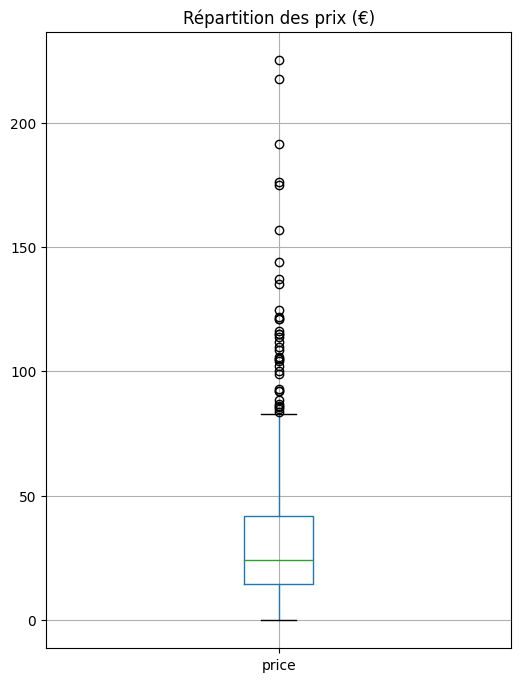

In [83]:
# Création de la boîte à moustaches avec Matplotlib
plt.figure(figsize=(6, 8))
df_erp_liaison_web.boxplot(column='price', grid=True)

# Ajout de titres
plt.title("Répartition des prix (€)")
plt.show()

In [84]:
#Autre méthode avec plotly express
import plotly.express as px

# Création de la boîte à moustaches avec Plotly Express
fig = px.box(df_erp_liaison_web, y='price', title="Répartition des prix (€)", labels={'price': 'Prix €'})
fig.update_layout(
    width=400,
    height=800,
    title_x=0.5,
    paper_bgcolor='white',  # Fond de la zone du graphique transparent
    plot_bgcolor='white',
    title_font=dict(family="Arial", size=20, color="black", weight="bold"),
    yaxis=dict(showgrid=True, gridcolor="lightgray", title=None),
    )

fig.update_traces(
    marker=dict(color="#ad283b"),
    boxmean=True)

# Affichage de la figure
fig.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">4.2 - Exploration par l'utilisation de méthodes statistiques</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">4.2.1 - Identification par le Z-score</h4>
</div>

In [85]:
# Calcul de la moyenne du prix
mean_price = df_erp_liaison_web['price'].mean()
print(f"Moyenne du prix : {mean_price:.2f} €")

# Calcul de l'écart-type du prix
std_price = df_erp_liaison_web['price'].std()
print(f"Écart-type du prix : {std_price:.2f} €")

# Calcul du Z-score pour chaque prix
df_erp_liaison_web['z_score'] = (df_erp_liaison_web['price'] - mean_price) / std_price

# Affichage des premiers Z-scores pour vérifier
display(df_erp_liaison_web[['price', 'z_score']].head())


Moyenne du prix : 32.23 €
Écart-type du prix : 26.65 €


,price,z_score
0,8.6,-0.886936
1,41.0,0.329039
2,39.0,0.253979
3,59.9,1.038358
4,22.5,-0.365268


In [86]:
# Quel est le seuil prix dont z-score est supérieur à 3?

# Trouver les prix dont le Z-score est supérieur à 3
outliers = df_erp_liaison_web[df_erp_liaison_web['z_score'] > 3]

# Afficher les prix correspondants et leur Z-score
print("Prix dont le Z-score est supérieur à 3 :")
display(outliers[['price', 'z_score']])
outliers[['price', 'z_score']].info()

# Affichage du seuil de prix uniquement (le prix minimum avec Z-score > 3)
seuil_prix = outliers['price'].min()
print(f"Seuil de prix dont le Z-score est supérieur à 3 : {seuil_prix:.2f} €")


Prix dont le Z-score est supérieur à 3 :


,price,z_score
24,176.0,5.395602
33,157.0,4.682530
87,115.0,3.106266
157,115.0,3.106266
171,137.0,3.931928
204,217.5,6.953101
233,114.0,3.068736
235,122.0,3.368977
256,124.8,3.474061
257,135.0,3.856868


<class 'pandas.core.frame.DataFrame'>
Index: 17 entries, 24 to 745
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   price    17 non-null     float64
 1   z_score  17 non-null     float64
dtypes: float64(2)
memory usage: 408.0 bytes
Seuil de prix dont le Z-score est supérieur à 3 : 114.00 €


<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">4.2.2 - Identification par l'intervalle interquartile</h4>
</div>

In [87]:
# Utilisation de la fonction describe pour obtenir les statistiques descriptives des prix
summary_stats = df_erp_liaison_web['price'].describe()
print("Statistiques descriptives des prix :")
display(summary_stats)

# Calcul du quartile 1 (Q1) et quartile 3 (Q3) et de l'intervalle interquartile (IQR)
Q1 = summary_stats['25%']
Q3 = summary_stats['75%']
IQR = Q3 - Q1

# Définition des seuils pour les outliers (valeurs qui sont en dehors de l'intervalle interquartile)
seuil_sup = Q3 + 1.5 * IQR
seuil_inf = Q1 - 1.5 * IQR

# Filtrage des outliers en fonction des seuils
outliers = df_erp_liaison_web[(df_erp_liaison_web['price'] < seuil_inf) | (df_erp_liaison_web['price'] > seuil_sup)]
outliers_sorted = outliers.sort_values(by='price', ascending=True)

# Afficher les outliers
print("Outliers détectés :")
display(outliers_sorted[["price"]])

# Calcul du nombre d'articles outliers et leur proportion dans l'ensemble du catalogue
num_outliers = len(outliers)
total_items = len(df_erp_liaison_web)
proportion_outliers = num_outliers / total_items * 100

print(f"Nombre d'articles outliers : {num_outliers}")
print(f"Proportion des articles outliers : {proportion_outliers:.2f}%")

Statistiques descriptives des prix :


count    825.000000
mean      32.232667
std       26.645280
min        0.000000
25%       14.500000
50%       24.300000
75%       42.000000
max      225.000000
Name: price, dtype: float64

Outliers détectés :


,price
156,83.7
762,84.7
143,85.6
734,86.1
149,86.8
56,88.4
730,92.0
770,92.0
234,93.0
53,99.0


Nombre d'articles outliers : 36
Proportion des articles outliers : 4.36%


In [88]:
# => haut de gamme

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">4.3 - TOP 20 des prix hauts</h3>
</div>

In [89]:
df_top_prix = df_erp_liaison_web.sort_values(by='price', ascending=False).reset_index(drop=True).head(20)
df_top_prix

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,tax_status,post_title,product_type,z_score
0,4352,1,225.0,0,outofstock,137.81,15940,15940,11.0,taxable,Champagne Egly-Ouriet Grand Cru Millésimé 2008,Champagne,7.234577
1,5001,1,217.5,18,instock,116.87,14581,14581,2.0,taxable,David Duband Charmes-Chambertin Grand Cru 2014,Vin,6.953101
2,5892,1,191.3,98,instock,116.06,14983,14983,6.0,taxable,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,Champagne,5.969813
3,4402,1,176.0,11,instock,78.25,3510,3510,3.0,taxable,Cognac Frapin VIP XO,Cognac,5.395602
4,5767,1,175.0,12,instock,90.42,15185,15185,4.0,taxable,Camille Giroud Clos de Vougeot 2016,Vin,5.358072
5,4406,1,157.0,12,instock,69.08,7819,7819,4.0,taxable,Cognac Frapin Château de Fontpinot 1989 20 Ans...,Cognac,4.682530
6,4594,1,144.0,0,outofstock,87.36,NaN,NaN,NaN,NaN,NaN,NaN,4.194639
7,4904,1,137.0,9,instock,67.95,14220,14220,3.0,taxable,Domaine Des Croix Corton Charlemagne Grand Cru...,Vin,3.931928
8,6126,1,135.0,138,instock,80.33,14923,14923,5.0,taxable,Champagne Gosset Célébris Vintage 2007,Champagne,3.856868
9,5612,1,124.8,19,instock,66.41,14915,14915,1.0,taxable,Domaine Weinbach Gewurztraminer Grand Cru Furs...,Vin,3.474061


In [90]:
# Graphique en barres horizontales des 20 premiers articles avec plotly express

fig_top_prix = px.bar(
    df_top_prix.sort_values(by='price', ascending=True),
    y='post_title',
    x='price',
    title="Top 20 des articles par chiffre d'affaires",
    labels={'post_title': '', 'price': 'Prix (€)'},
    orientation='h',
    color_discrete_sequence=['#cc4e5c'],
    text_auto=True
)

# Mise à jour du style des valeurs affichées
fig_top_prix.update_traces(
    textposition='outside',  # Texte en dehors des barres
    textfont=dict(color='black')  # Texte en noir
)

fig_top_prix.update_layout(
    title_x=0.5,  # Centre le titre
    plot_bgcolor='white',  # Fond du graphique blanc
    paper_bgcolor='white',  # Fond global blanc
    width=1200,  # Largeur du graphique
    height=1000  # Hauteur du graphique
)

fig_top_prix.show()

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">ETAPE 5 : ANALYSE UNIVARIEE DU CA, VENTES, STOCKS ET MARGE</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">5.1 - Analyse des ventes en CA</h3>
</div>

In [91]:
##############################
# Calculer le CA su site web #
##############################
# Créez une colonne calculant le CA par article
df_erp_liaison_web['ca_par_article'] = df_erp_liaison_web['price'] * df_erp_liaison_web['total_sales']

# Calculez la somme de la colonne "ca_par_article"
ca_total = df_erp_liaison_web['ca_par_article'].sum()
print(f"Le chiffre d'affaires total du site web est de : {ca_total:,.2f} €".replace(',', ' '))
#Ce résultat correspond au chiffre d'affaire du site web


Le chiffre d'affaires total du site web est de : 143 680.10 €


In [92]:
###############################
# Palmares des articles en CA #
###############################
# Effectuer le tri dans l'ordre décroissant du CA du dataset df_erp_liaison_web
df_ca_tri = df_erp_liaison_web.sort_values(by='ca_par_article', ascending=False)

# Réinitialiser l'index du dataset par un reset_index
df_ca_tri = df_ca_tri.reset_index(drop=True)

# Afficher les 20 premiers articles en CA
top_20_ca = df_ca_tri.head(20)
print("Top 20 des articles par chiffre d'affaires:")
display(top_20_ca[['product_id', 'post_title', 'ca_par_article', 'total_sales',"price"]])

# Graphique en barres horizontales des 20 premiers articles avec plotly express

fig_top_ca = px.bar(
    top_20_ca,
    y='post_title',
    x='ca_par_article',
    title="Top 20 des articles par chiffre d'affaires",
    labels={'post_title': '', 'ca_par_article': "Chiffre d'affaires (€)"},
    orientation='h',
    color_discrete_sequence=['#cc4e5c'],
    text_auto=True
)

# Mise à jour du style des valeurs affichées
fig_top_ca.update_traces(
    textposition='outside',  # Texte en dehors des barres
    textfont=dict(color='black')  # Texte en noir
)

fig_top_ca.update_layout(
    yaxis={'categoryorder': 'total ascending'},
    title_x=0.5,  # Centre le titre
    plot_bgcolor='white',  # Fond du graphique blanc
    paper_bgcolor='white',  # Fond global blanc
    width=1200,  # Largeur du graphique
    height=1000  # Hauteur du graphique
)

fig_top_ca.show()

Top 20 des articles par chiffre d'affaires:


,product_id,post_title,ca_par_article,total_sales,price
0,4352,Champagne Egly-Ouriet Grand Cru Millésimé 2008,2475.0,11.0,225.0
1,5892,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,1147.8,6.0,191.3
2,4353,Champagne Egly-Ouriet Grand Cru Brut Rosé,1113.0,14.0,79.5
3,5826,Agnès Levet Côte Rôtie Améthyste 2017,824.0,20.0,41.2
4,6212,Domaine des Comtes Lafon Volnay 1er Cru Santen...,805.0,7.0,115.0
5,5026,Champagne Agrapart &amp; Fils Minéral Extra Br...,781.2,9.0,86.8
6,5008,Domaine des Comtes Lafon Volnay 1er Cru Santen...,735.0,7.0,105.0
7,5767,Camille Giroud Clos de Vougeot 2016,700.0,4.0,175.0
8,6126,Champagne Gosset Célébris Vintage 2007,675.0,5.0,135.0
9,5025,Champagne Agrapart &amp; Fils L'Avizoise Extra...,672.0,6.0,112.0


In [93]:
top_20ca_sorted = top_20_ca.sort_values(by="price", ascending= False)
top_20ca_sorted[["post_title", "price", "ca_par_article"]]

,post_title,price,ca_par_article
0,Champagne Egly-Ouriet Grand Cru Millésimé 2008,225.0,2475.0
1,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,191.3,1147.8
19,Cognac Frapin VIP XO,176.0,528.0
7,Camille Giroud Clos de Vougeot 2016,175.0,700.0
11,Cognac Frapin Château de Fontpinot 1989 20 Ans...,157.0,628.0
8,Champagne Gosset Célébris Vintage 2007,135.0,675.0
16,Domaine Clerget Echezeaux Grand Cru En Orveaux...,116.4,582.0
4,Domaine des Comtes Lafon Volnay 1er Cru Santen...,115.0,805.0
9,Champagne Agrapart &amp; Fils L'Avizoise Extra...,112.0,672.0
10,David Duband Chambolle-Musigny 1er Cru Les Sen...,105.6,633.6


In [94]:
top_20_ca_84a114 = (top_20_ca[(top_20_ca["price"] >= 83.7) & (top_20_ca["price"] <= 114)]["price"].count()) * 100 / 20
print(f"{top_20_ca_84a114:.1f}% des articles du Top20 CA ont un prix compris entre 83.7 et 114 euros.")

30.0% des articles du Top20 CA ont un prix compris entre 83.7 et 114 euros.


In [95]:
top_20_ca_sup114 = (top_20_ca[top_20_ca["price"] >= 114]["price"].count())*100/20
print(f"{top_20_ca_sup114:.1f}% des articles du Top20 CA ont un prix supérieur à 114 euros")

40.0% des articles du Top20 CA ont un prix supérieur à 114 euros


In [96]:
#############################
# Calculer le 20 / 80 en CA #
#############################
# Créer une colonne calculant la part du CA de la ligne dans le dataset
df_ca_tri['part_ca'] = df_ca_tri['ca_par_article'] / ca_total * 100
display(df_ca_tri)

# Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_ca_tri['part_ca_cumul'] = df_ca_tri['part_ca'].cumsum()
display(df_ca_tri)

# Grâce au deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% du CA
nb_articles_80pc_ca = df_ca_tri[df_ca_tri['part_ca_cumul'] <= 80].shape[0] + 1
print(f"Nombre d'articles représentant 80% du CA : {nb_articles_80pc_ca}")

# Afficher la proportion que représentent ce groupe d'articles dans le catalogue entier du site web
proportion_articles_80pc_ca = (nb_articles_80pc_ca / df_erp_liaison_web.shape[0]) * 100
print(f"Ces articles représentent {proportion_articles_80pc_ca:.2f}% du catalogue entier")

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,tax_status,post_title,product_type,z_score,ca_par_article,part_ca
0,4352,1,225.0,0,outofstock,137.81,15940,15940,11.0,taxable,Champagne Egly-Ouriet Grand Cru Millésimé 2008,Champagne,7.234577,2475.0,1.722577
1,5892,1,191.3,98,instock,116.06,14983,14983,6.0,taxable,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,Champagne,5.969813,1147.8,0.798858
2,4353,1,79.5,127,instock,45.91,12587,12587,14.0,taxable,Champagne Egly-Ouriet Grand Cru Brut Rosé,Champagne,1.773948,1113.0,0.774638
3,5826,1,41.2,34,instock,21.71,15325,15325,20.0,taxable,Agnès Levet Côte Rôtie Améthyste 2017,Vin,0.336545,824.0,0.573496
4,6212,1,115.0,16,instock,59.42,13996,13996,7.0,taxable,Domaine des Comtes Lafon Volnay 1er Cru Santen...,Vin,3.106266,805.0,0.560272
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
820,7196,0,31.0,55,instock,31.20,NaN,NaN,NaN,NaN,NaN,NaN,-0.046262,NaN,NaN
821,7200,0,31.0,6,instock,15.54,NaN,NaN,NaN,NaN,NaN,NaN,-0.046262,NaN,NaN
822,7201,0,31.0,18,instock,16.02,NaN,NaN,NaN,NaN,NaN,NaN,-0.046262,NaN,NaN
823,7203,0,45.0,30,instock,23.48,NaN,NaN,NaN,NaN,NaN,NaN,0.479159,NaN,NaN


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,tax_status,post_title,product_type,z_score,ca_par_article,part_ca,part_ca_cumul
0,4352,1,225.0,0,outofstock,137.81,15940,15940,11.0,taxable,Champagne Egly-Ouriet Grand Cru Millésimé 2008,Champagne,7.234577,2475.0,1.722577,1.722577
1,5892,1,191.3,98,instock,116.06,14983,14983,6.0,taxable,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,Champagne,5.969813,1147.8,0.798858,2.521435
2,4353,1,79.5,127,instock,45.91,12587,12587,14.0,taxable,Champagne Egly-Ouriet Grand Cru Brut Rosé,Champagne,1.773948,1113.0,0.774638,3.296072
3,5826,1,41.2,34,instock,21.71,15325,15325,20.0,taxable,Agnès Levet Côte Rôtie Améthyste 2017,Vin,0.336545,824.0,0.573496,3.869569
4,6212,1,115.0,16,instock,59.42,13996,13996,7.0,taxable,Domaine des Comtes Lafon Volnay 1er Cru Santen...,Vin,3.106266,805.0,0.560272,4.429841
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
820,7196,0,31.0,55,instock,31.20,NaN,NaN,NaN,NaN,NaN,NaN,-0.046262,NaN,NaN,NaN
821,7200,0,31.0,6,instock,15.54,NaN,NaN,NaN,NaN,NaN,NaN,-0.046262,NaN,NaN,NaN
822,7201,0,31.0,18,instock,16.02,NaN,NaN,NaN,NaN,NaN,NaN,-0.046262,NaN,NaN,NaN
823,7203,0,45.0,30,instock,23.48,NaN,NaN,NaN,NaN,NaN,NaN,0.479159,NaN,NaN,NaN


Nombre d'articles représentant 80% du CA : 435
Ces articles représentent 52.73% du catalogue entier


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">5.2 - Analyse des ventes en quantité</h3>
</div>

In [97]:
print(df_erp_liaison_web['total_sales'].sum())

5751.0


In [98]:
#####################################
# Palmares des articles en quantité #
#####################################
# Effectuer le tri dans l'ordre décroissant de quantités vendues du dataset df_erp_liaison_web
df_qty_tri = df_erp_liaison_web.sort_values(by='total_sales', ascending=False)

# Réinitialiser l'index du dataset par un reset_index
df_qty_tri = df_qty_tri.reset_index(drop=True)

# Afficher les 20 premier articles en quantité
top_20_qty = df_qty_tri.head(20)
print("Top 20 des articles par quantité vendue:")
display(top_20_qty[['product_id', 'post_title', 'total_sales', 'ca_par_article', 'price']])

# Graphique en barres horizontales des 20 premiers articles par quantité vendue
fig_top_qty = px.bar(
    top_20_qty,
    y='post_title',  # Axe y pour les noms de produits
    x='total_sales',  # Axe x pour la quantité vendue
    title='Top 20 des articles par quantité vendue',
    labels={'post_title': '', 'total_sales': 'Quantité vendue'},  # Suppression du titre d'axe
    orientation='h',  # Orientation horizontale
    color_discrete_sequence=['dark grey'],
    text_auto=True
)
# Mise à jour du style des valeurs affichées
fig_top_qty.update_traces(
    textposition='outside',  # Texte en dehors des barres
    textfont=dict(color='black')  # Texte en noir
)
fig_top_qty.update_layout(
    yaxis={'categoryorder': 'total ascending'},  # Trie les catégories de bas en haut
    title_x=0.5,  # Centre le titre du graphique
    plot_bgcolor='white',  # Fond du graphique blanc
    paper_bgcolor='white',  # Fond global blanc
    width=1200,  # Largeur du graphique
    height=1000  # Hauteur du graphique
)
fig_top_qty.show()

top_20_qty.describe()

Top 20 des articles par quantité vendue:


,product_id,post_title,total_sales,ca_par_article,price
0,4867,Château De La Selve IGP Coteaux de l'Ardèche M...,36.0,356.4,9.9
1,4203,Mas Laval IGP Pays d'Hérault Les Pampres Blanc...,27.0,267.3,9.9
2,4275,I Fabbri Chianti Classico Lamole 2017,24.0,357.6,14.9
3,4647,Bernard Baudry Chinon Rouge La Croix Boissée 2017,22.0,627.0,28.5
4,4726,François Baur Pinot Noir Schlittweg 2017,22.0,279.4,12.7
5,5826,Agnès Levet Côte Rôtie Améthyste 2017,20.0,824.0,41.2
6,6129,Moulin de Gassac IGP Pays d'Hérault Guilhem Bl...,20.0,104.0,5.2
7,4220,Xavier Frissant Touraine Amboise Chenin Les Pi...,18.0,208.8,11.6
8,5778,Maurel Pays d'Oc Merlot 2018,17.0,98.6,5.8
9,6569,Decelle-Villa Chorey-Lès-Beaune 2016,17.0,493.0,29.0


,product_id,onsale_web,price,stock_quantity,purchase_price,total_sales,z_score,ca_par_article
count,20.00000,20.0,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,4950.70000,1.0,12.755000,45.900000,6.604000,19.100000,-0.730999,250.050000
std,805.73772,0.0,9.504042,27.368634,4.968291,5.159559,0.356688,199.426429
min,4059.00000,1.0,5.200000,0.000000,2.740000,15.000000,-1.014539,85.500000
25%,4215.75000,1.0,6.725000,34.000000,3.525000,16.000000,-0.957305,107.600000
50%,4794.50000,1.0,9.400000,47.500000,4.835000,17.000000,-0.856912,150.400000
75%,5777.25000,1.0,13.250000,55.000000,7.060000,20.500000,-0.712421,307.125000
max,6569.00000,1.0,41.200000,121.000000,21.710000,36.000000,0.336545,824.000000


In [99]:
#############################
# Calculer le 20 / 80 en quantité #
#############################
# Créer une colonne calculant la part en quantité de la ligne dans le dataset
total_sales = df_erp_liaison_web['total_sales'].sum()
df_qty_tri['part_qty'] = df_qty_tri['total_sales'] / total_sales * 100

# Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_qty_tri['part_qty_cumul'] = df_qty_tri['part_qty'].cumsum()

# Grâce au deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% des ventes en quantité
nb_articles_80pc_qty = df_qty_tri[df_qty_tri['part_qty_cumul'] <= 80].shape[0] + 1
print(f"Nombre d'articles représentant 80% des ventes en quantité : {nb_articles_80pc_qty}")

# Afficher la proportion que représentent ce groupe d'articles dans le catalogue entier du site web
proportion_articles_80pc_qty = (nb_articles_80pc_qty / df_erp_liaison_web.shape[0]) * 100
print(f"Ces articles représentent {proportion_articles_80pc_qty:.2f}% du catalogue entier")

Nombre d'articles représentant 80% des ventes en quantité : 434
Ces articles représentent 52.61% du catalogue entier


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">5.3 - Analyse des stocks</h3>
</div>

In [100]:
######################################
# Calcule le nombre de mois de stock #
######################################
# Import de numpy
import numpy as np

# Création de la colonne Rotation de stock (en mois)
# On divise le stock par les ventes mensuelles moyennes (total_sales / 12)
df_erp_liaison_web['mois_de_stock'] = np.where(
    df_erp_liaison_web['total_sales'] > 0,
    (df_erp_liaison_web['stock_quantity'] / (df_erp_liaison_web['total_sales'] / 12)),
    0)  # Si aucune vente, on met 0

# Effectuer le tri dans l'ordre décroissant du nombre de mois de stock dans le dataset df_erp_liaison_web
df_stock_tri_desc = df_erp_liaison_web.sort_values(by='mois_de_stock', ascending=False).reset_index(drop=True)
flop_20_stock = df_stock_tri_desc.head(20)
print("Flop 20 des stocks :")
display(flop_20_stock[['post_title', 'mois_de_stock', 'purchase_price']])

# Effectuer le tri dans l'ordre croissant du nombre de mois de stock dans le dataset df_erp_liaison_web
df_stock_tri_asc = df_erp_liaison_web.sort_values(by='mois_de_stock', ascending=True).reset_index(drop=True)
top_20_stock = df_stock_tri_asc.head(20)
print("Top 20 des stocks : ")
display(top_20_stock[['post_title', 'mois_de_stock', 'purchase_price']])

Flop 20 des stocks :


,post_title,mois_de_stock,purchase_price
0,Champagne Gosset Grand Millésime 2006,375.000000,32.15
1,Champagne Gosset Célébris Vintage 2007,331.200000,80.33
2,Champagne Egly-Ouriet Premier Cru Les Vignes d...,324.000000,31.00
3,Champagne Egly-Ouriet Grand Cru Brut Tradition,300.000000,34.76
4,Champagne Mailly Grand Cru Brut Rosé,284.000000,21.88
5,Champagne Larmandier-Bernier Latitude,276.000000,22.30
6,Champagne Gosset Grand Rosé,273.000000,27.73
7,Champagne Agrapart &amp; Fils L'Avizoise Extra...,272.000000,68.60
8,Champagne Egly-Ouriet Grand Cru Extra Brut V.P.,248.571429,47.30
9,Champagne Mailly Grand Cru Intemporelle 2010,246.000000,35.45


Top 20 des stocks : 


,post_title,mois_de_stock,purchase_price
0,NaN,0.0,16.02
1,NaN,0.0,15.54
2,NaN,0.0,23.48
3,NaN,0.0,23.95
4,NaN,0.0,24.18
5,NaN,0.0,14.73
6,NaN,0.0,13.43
7,NaN,0.0,15.66
8,NaN,0.0,10.44
9,NaN,0.0,24.18


In [101]:
# Graphique en barres horizontales du flop 20 des produits avec le plus de mois de stock
fig_flop_stock = px.bar(
    flop_20_stock,
    y='post_title',  # Axe y pour les noms de produits
    x='mois_de_stock',  # Axe x pour les mois de stock
    title='Flop 20 des produits avec le plus grand nombre de mois de stock',
    labels={'post_title': '', 'mois_de_stock': 'Mois de stock'},  # Suppression du titre d'axe
    orientation='h',  # Orientation horizontale
    color_discrete_sequence=['#fe96a0'],  # Couleur des barres
    text_auto=True
)

# Mise à jour du style des valeurs affichées
fig_flop_stock.update_traces(
    textposition='outside',  # Texte en dehors des barres
    textfont=dict(color='black')  # Texte en noir
)

fig_flop_stock.update_layout(
    yaxis={'categoryorder': 'total ascending'},  # Trie les catégories de bas en haut
    title_x=0.5,  # Centre le titre du graphique
    plot_bgcolor='white',  # Fond du graphique blanc
    paper_bgcolor='white',  # Fond global blanc
    width=1200,  # Largeur du graphique
    height=1000  # Hauteur du graphique
)
fig_flop_stock.show()

In [102]:
####################################
# Valorisation des stocks en euros #
####################################
# Création de la colonne Valorisation des stocks en euros
df_erp_liaison_web['valorisation_stock_euros'] = df_erp_liaison_web['stock_quantity'] * df_erp_liaison_web['purchase_price']

# Calculer la somme de la colonne "Valorisation_stock_euros"
valorisation_totale = df_erp_liaison_web['valorisation_stock_euros'].sum()
print(f"Valorisation totale des stocks : {valorisation_totale:,.2f} €".replace(',', ' '))

Valorisation totale des stocks : 298 627.66 €


In [103]:
##############################################
# Valorisation du nombre de produit en stock #
##############################################
# Calculer la somme de la colonne stock quantity
total_stock = df_erp_liaison_web['stock_quantity'].sum()
print(f"Nombre total de produits en stock : {total_stock:,}".replace(',', ' '))

Nombre total de produits en stock : 17 822


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">5.4 - Analyse du taux de marge</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">5.4.1 - Création colonnes Prix HT et Taux de marge </h4>
</div>

In [104]:
# Création des colonnes prix HT (en supposant un taux de TVA de 20%)
tva = 0.20  # 20% de TVA
df_erp_liaison_web['price_ht'] = df_erp_liaison_web['price'] / (1 + tva)
df_erp_liaison_web['purchase_price_ht'] = df_erp_liaison_web['purchase_price'] / (1 + tva)

# Création de la colonne Taux de marge
df_erp_liaison_web['taux_marge'] = (df_erp_liaison_web['price_ht'] - df_erp_liaison_web['purchase_price_ht']) * 100 / df_erp_liaison_web['purchase_price_ht']
display(df_erp_liaison_web)

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,tax_status,post_title,product_type,z_score,ca_par_article,mois_de_stock,valorisation_stock_euros,price_ht,purchase_price_ht,taux_marge
0,4729,1,8.6,26,instock,4.22,38,38,10.0,taxable,Emile Boeckel Crémant Brut Blanc de Blancs,Vin,-0.886936,86.0,31.2,109.72,7.166667,3.516667,103.791469
1,4634,1,41.0,11,instock,20.12,41,41,6.0,taxable,Marcel Windholtz Eau de Vie de Marc de Gewurzt...,Vin,0.329039,246.0,22.0,221.32,34.166667,16.766667,103.777336
2,4141,1,39.0,123,instock,24.86,304,304,8.0,taxable,Champagne Gosset Grande Réserve,Champagne,0.253979,312.0,184.5,3057.78,32.500000,20.716667,56.878520
3,5932,1,59.9,13,instock,27.18,523,523,0.0,taxable,Cognac Normandin Mercier VFC,Cognac,1.038358,0.0,0.0,353.34,49.916667,22.650000,120.382634
4,5047,1,22.5,76,instock,13.78,531,531,8.0,taxable,Champagne Petit Lebrun &amp; Fils Blanc de Bla...,Champagne,-0.365268,180.0,114.0,1047.28,18.750000,11.483333,63.280116
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
820,7196,0,31.0,55,instock,31.20,NaN,NaN,NaN,NaN,NaN,NaN,-0.046262,NaN,0.0,1716.00,25.833333,26.000000,-0.641026
821,7200,0,31.0,6,instock,15.54,NaN,NaN,NaN,NaN,NaN,NaN,-0.046262,NaN,0.0,93.24,25.833333,12.950000,99.485199
822,7201,0,31.0,18,instock,16.02,NaN,NaN,NaN,NaN,NaN,NaN,-0.046262,NaN,0.0,288.36,25.833333,13.350000,93.508115
823,7203,0,45.0,30,instock,23.48,NaN,NaN,NaN,NaN,NaN,NaN,0.479159,NaN,0.0,704.40,37.500000,19.566667,91.652470


<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">5.4.2 - Taux de marge mini, maxi, nuls </h4>
</div>

In [105]:
# Afficher taux de marge mini
print(f"Taux de marge minimum : {df_erp_liaison_web['taux_marge'].min():.2f}%")

# Afficher taux de marge maxi
print(f"Taux de marge maximum : {df_erp_liaison_web['taux_marge'].max():.2f}%")

Taux de marge minimum : -100.00%
Taux de marge maximum : 129.69%


In [106]:
##############################################
# DETAILS TAUX DE MARGE STRICTEMENT NEGATIFS #
##############################################

# Affichage des lignes avec un taux de marge inférieur à 0
df_marges_negatives = df_erp_liaison_web[df_erp_liaison_web['taux_marge'] < 0]
print(f"Nombre de produits avec une marge négative : {df_marges_negatives.shape[0]}")
print('Lignes concernées:')
display(df_marges_negatives[['product_id', 'post_title', 'taux_marge', 'price_ht', 'purchase_price_ht']])

Nombre de produits avec une marge négative : 7
Lignes concernées:


,product_id,post_title,taux_marge,price_ht,purchase_price_ht
79,4355,Champagne Egly-Ouriet Grand Cru Blanc de Noirs,-83.673206,10.541667,64.566667
303,4864,NaN,-16.916917,6.916667,8.325000
739,4233,NaN,-100.000000,0.000000,8.608333
760,5017,NaN,-100.000000,0.000000,3.616667
770,6324,NaN,-7.070707,76.666667,82.500000
772,6594,NaN,-100.000000,0.000000,3.841667
820,7196,NaN,-0.641026,25.833333,26.000000


In [107]:
# 3 articles avec un taux de marge à -100% dû au fait d'avoir ramené les prix négatifs à 0 lors du nettoyage.
# /!\ pour les autres prix, erreur de saisie ?

In [108]:
##############################################
# DETAILS TAUX DE MARGE STRICTEMENT POSITIFS #
##############################################

# Création d'un dataframe avec les taux positifs
df_marges_positives = df_erp_liaison_web[df_erp_liaison_web['taux_marge'] > 0]

# Afficher le prix minimum de la colonne "taux_marge" pour les marges positives
print(f"Taux de marge minimum (positif) : {df_marges_positives['taux_marge'].min():.2f}%")

# Afficher le prix maximum de la colonne "taux_marge" pour les marges positives
print(f"Taux de marge maximum (positif) : {df_marges_positives['taux_marge'].max():.2f}%")

Taux de marge minimum (positif) : 55.40%
Taux de marge maximum (positif) : 129.69%


In [109]:
##############################
# DETAILS TAUX DE MARGE NULS #
##############################

# Création d'un dataframe avec les taux nuls
df_marges_nulles = df_erp_liaison_web[df_erp_liaison_web['taux_marge'] == 0]
df_marges_nulles[['product_id', 'post_title', 'taux_marge', 'price', 'purchase_price', 'onsale_web']]

,product_id,post_title,taux_marge,price,purchase_price,onsale_web


In [110]:
df_marges_positives = df_erp_liaison_web[(df_erp_liaison_web['taux_marge'] > 0) & (df_erp_liaison_web['purchase_price'] > 0)]
# df_marges_positives = df_erp_liaison_web[(df_erp_liaison_web['taux_marge'] > 0)]

print('Nombre de lignes de df_marges_positives :', df_marges_positives.shape[0])

Nombre de lignes de df_marges_positives : 818


<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">5.4.3 - Taux de marge par type de produit </h4>
</div>

In [111]:
# Calcul du taux de marge moyen par type de produit
marges_par_type = df_marges_positives.groupby('product_type')['taux_marge'].mean().reset_index()
print("Taux de marge moyen (%) par type de produit:")
display(marges_par_type)

Taux de marge moyen (%) par type de produit:


,product_type,taux_marge
0,Champagne,67.945545
1,Cognac,118.779435
2,Gin,109.790210
3,Huile d'olive,60.068162
4,Vin,93.795313
5,Whisky,118.087005


In [112]:
# Affichage dans un graphique du taux de marge par type de produit
fig_marges = px.bar(
    marges_par_type,
    x='taux_marge',
    y='product_type',
    title='Taux de marge moyen par type de produit',
    labels={'product_type': 'Type de produit', 'taux_marge': 'Taux de marge moyen (%)'},
    orientation='h',
    text_auto=True

)
fig_marges.update_traces(
    textposition='outside',
    textfont=dict(color='black')
)
fig_marges.update_layout(
    yaxis={'categoryorder': 'total ascending'},
    title_x=0.5,  # Centre le titre du graphique
    plot_bgcolor='white',  # Fond du graphique blanc
    paper_bgcolor='white',  # Fond global blanc
    width=600,  # Largeur du graphique
    height=600,
    xaxis_range=[0, 150]
)

fig_marges.show()


<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">5.4.4 - Taux de marge Top 20 </h4>
</div>

In [113]:
# Effectuer le tri dans l'ordre décroissant de la marge positive
df_marge_positive_tri = df_marges_positives.sort_values(by='taux_marge', ascending=False).reset_index(drop=True)
df_marge_positive_top20 = df_marge_positive_tri.head(20)
display(df_marge_positive_top20[['post_title', 'taux_marge','price']])

,post_title,taux_marge,price
0,Cognac Frapin VSOP,129.694965,62.5
1,Wemyss Malts Single Cask Scotch Whisky Chocola...,129.686342,93.0
2,NaN,127.296727,86.1
3,Cognac Frapin Château de Fontpinot 1989 20 Ans...,127.272727,157.0
4,Kingsbarns Distillery Lowland Single Malt Whisky,127.272727,57.0
5,Wemyss Malts Single Cask Scotch Whisky Choc 'n...,124.926254,122.0
6,Cognac Frapin VIP XO,124.920128,176.0
7,Wemyss Malts Blended Malt Scotch Whisky Spice ...,124.897774,49.5
8,Wemyss Malts Blended Malt Scotch Whisky Peat C...,124.897774,49.5
9,NaN,122.659800,73.5


In [114]:
df_marge_positive_top20[["price"]].describe()

,price
count,20.000000
mean,82.095000
std,35.714577
min,49.500000
25%,59.000000
50%,65.300000
75%,95.750000
max,176.000000


In [115]:
# Graphique en barres horizontales du flop 20 des produits avec le plus de mois de stock
fig_top20_marge = px.bar(
    df_marge_positive_top20.sort_values(by='taux_marge', ascending=True),
    y='post_title',  # Axe y pour les noms de produits
    x='taux_marge',  # Axe x pour le taux de marge
    title='Top 20 des produits avec le plus de marge',
    labels={'post_title': '', 'taux_marge': 'Taux de marge (%)'},  # Suppression du titre d'axe
    orientation='h',  # Orientation horizontale
    color_discrete_sequence=['orange'],
    text_auto=True
)

# Mise à jour du style des valeurs affichées
fig_top20_marge.update_traces(
    textposition='outside',  # Texte en dehors des barres
    textfont=dict(color='black')  # Texte en noir
)

fig_top20_marge.update_layout(
    title_x=0.5,  # Centre le titre du graphique
    plot_bgcolor='white',  # Fond du graphique blanc
    paper_bgcolor='white',  # Fond global blanc
    width=1200,  # Largeur du graphique
    height=1000,  # Hauteur du graphique
    xaxis_range=[0, 180]
)

display(fig_top20_marge)

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">ETAPE 6 : ANALYSE MULTIVARIEE : CA, VENTES, STOCKS ET MARGE</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">5.5 - Analyse des correlations entre les variables stock, sales et price</h3>
</div>

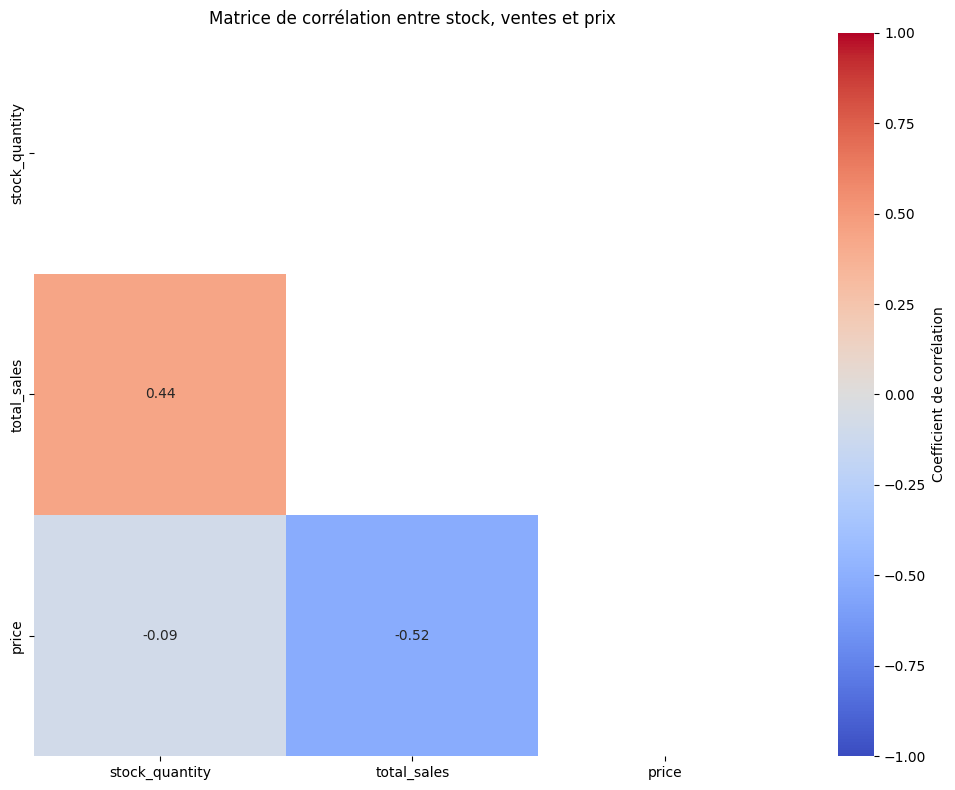

In [116]:
############################
# Analyse des correlations #
############################
import seaborn as sns
import matplotlib.pyplot as plt

# Sélection des variables pour la corrélation
df_corr = df_erp_liaison_web[['stock_quantity', 'total_sales', 'price']].copy()

# Calcul de la matrice de corrélation
corr_matrix = df_corr.corr()

# Création d'un mask pour n'afficher qu'une demi heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Configuration de la figure
plt.figure(figsize=(10, 8))

# Création du heatmap de correlation avec les variables stock, sales et price
# on peut également créer un mask pour n'afficher qu'une demi heatmap
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    mask=mask,
    vmin=-1,
    vmax=1,
    cbar_kws={'label': 'Coefficient de corrélation'}
)
plt.title('Matrice de corrélation entre stock, ventes et prix')
plt.tight_layout()
plt.show()

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">ETAPE 7 : EXPORT DATASET FINAL AU FORMAT EXCEL</h2>
</div>

In [117]:
df_erp_liaison_web

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,tax_status,post_title,product_type,z_score,ca_par_article,mois_de_stock,valorisation_stock_euros,price_ht,purchase_price_ht,taux_marge
0,4729,1,8.6,26,instock,4.22,38,38,10.0,taxable,Emile Boeckel Crémant Brut Blanc de Blancs,Vin,-0.886936,86.0,31.2,109.72,7.166667,3.516667,103.791469
1,4634,1,41.0,11,instock,20.12,41,41,6.0,taxable,Marcel Windholtz Eau de Vie de Marc de Gewurzt...,Vin,0.329039,246.0,22.0,221.32,34.166667,16.766667,103.777336
2,4141,1,39.0,123,instock,24.86,304,304,8.0,taxable,Champagne Gosset Grande Réserve,Champagne,0.253979,312.0,184.5,3057.78,32.500000,20.716667,56.878520
3,5932,1,59.9,13,instock,27.18,523,523,0.0,taxable,Cognac Normandin Mercier VFC,Cognac,1.038358,0.0,0.0,353.34,49.916667,22.650000,120.382634
4,5047,1,22.5,76,instock,13.78,531,531,8.0,taxable,Champagne Petit Lebrun &amp; Fils Blanc de Bla...,Champagne,-0.365268,180.0,114.0,1047.28,18.750000,11.483333,63.280116
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
820,7196,0,31.0,55,instock,31.20,NaN,NaN,NaN,NaN,NaN,NaN,-0.046262,NaN,0.0,1716.00,25.833333,26.000000,-0.641026
821,7200,0,31.0,6,instock,15.54,NaN,NaN,NaN,NaN,NaN,NaN,-0.046262,NaN,0.0,93.24,25.833333,12.950000,99.485199
822,7201,0,31.0,18,instock,16.02,NaN,NaN,NaN,NaN,NaN,NaN,-0.046262,NaN,0.0,288.36,25.833333,13.350000,93.508115
823,7203,0,45.0,30,instock,23.48,NaN,NaN,NaN,NaN,NaN,NaN,0.479159,NaN,0.0,704.40,37.500000,19.566667,91.652470


In [118]:
# Mettre le dataset df_erp_liaison_web dans un fichier Excel
df_erp_liaison_web.to_excel('donnees_erp_web.xlsx', index=False)
print("Le fichier Excel 'donnees_erp_web.xlsx' a été créé avec succès.")

Le fichier Excel 'donnees_erp_web.xlsx' a été créé avec succès.
